# IDRiD — **Deep Clustering** → Multi-class DR Classifier (levels 0–4)

**Generated:** 2025-08-21

This notebook implements an **iterative Deep Clustering** pretext stage:
1) Start with ImageNet EfficientNet-B0.
2) **Iteratively**: extract features → **k-means** (C clusters) → train network to predict cluster ids (balanced sampling).
3) Transfer the learned backbone → **multi-class fine-tuning** (No DR vs DR).

**Extras**: circular fundus crop, optional CLAHE, stratified 70/15/15 split, HPO for fine-tuning, confusion matrix, ROC/PR.

**Data paths**:
- CSV: `/kaggle/input/idrid-dataset/idrid_labels.csv`
- Images: `/kaggle/input/idrid-dataset/Imagenes/Imagenes/{id_code}.jpg`


## 1) Setup & Config

In [1]:

# ==== Training CONFIG (performance-focused) ====
INPUT_RESIZE = 512          # resize (square for simplicity)
INPUT_CROP   = 448          # final crop size
USE_MIXUP    = True         # MixUp in training
MIXUP_ALPHA  = 0.4
USE_TTA      = True         # test-time augmentation
TTA_K        = 4            # 4 simple variants
WEIGHTED_SAMPLER = False    # prefer CB-Focal first; set True if tails still weak
LOSS_NAME    = "cb_focal"   # "cb_focal" or "ce"
CB_BETA      = 0.999
FOCAL_GAMMA  = 2.0
GRAD_CLIP_NORM = 1.0


In [2]:

# ==== Loss utilities: Effective Number weights + Focal Loss ====
import numpy as _np
import torch.nn as _nn

def effective_num_weights_numpy(labels, beta=0.999):
    labels = _np.asarray(labels)
    K = int(labels.max()) + 1
    counts = _np.bincount(labels, minlength=K).astype(_np.float32)
    eff_num = 1.0 - _np.power(beta, counts)
    weights = (1.0 - beta) / _np.maximum(eff_num, 1e-8)
    weights = weights / weights.sum() * K
    return weights

class FocalLoss(_nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction
        self.ce = _nn.CrossEntropyLoss(weight=weight, reduction="none")
    def forward(self, logits, target):
        ce = self.ce(logits, target)          # [B]
        with torch.no_grad():
            pt = torch.softmax(logits, dim=1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-8)
        loss = (1 - pt)**self.gamma * ce
        if self.reduction == "mean": return loss.mean()
        if self.reduction == "sum":  return loss.sum()
        return loss


In [3]:

import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_curve, roc_auc_score, precision_recall_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
seed_everything()

# ==== Preprocessing toggles ====
ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

# ==== Deep Clustering config ====
PRETEXT_CLUSTERS = 10          # number of clusters for deep clustering (try 10~50)
DC_EPOCHS_PER_CYCLE = 10        # train epochs per clustering cycle
DC_CYCLES = 7                  # number of (cluster -> train) cycles
DC_BATCH_SIZE = 32             # larger batch helps

# Feature extraction stability
PCA_DIM = 128                  # PCA dim for clustering stability (set None to disable)
L2_NORMALIZE = True

# ==== Fine-tuning HPO ====
SWEEP_LR = [1e-4, 3e-4]
SWEEP_WD = [1e-5, 1e-4]
SWEEP_DROPOUT = [0.2, 0.4]
SWEEP_EPOCHS = 6
FINAL_EPOCHS = 15
FT_BATCH_SIZE = 32


Device: cuda


## 2) Load CSV, Map to Binary (No DR=0, DR≥1=1) & Image Paths

In [4]:

CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

# Robust read
try:
    df = pd.read_csv(CSV_PATH)
    df.columns = [c.strip() for c in df.columns]
except Exception:
    df = pd.read_csv(CSV_PATH, usecols=[0,1])
    df.columns = ["id_code", "diagnosis"]

df = df[[c for c in df.columns if c.lower() in ("id_code","diagnosis")]].copy()
df.columns = ["id_code","diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = df["diagnosis"].astype(int)

from pathlib import Path
def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg",".JPG",".png",".jpeg",".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists(): return str(p)
    return str(base.with_suffix(".jpg"))

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nClass distribution (0–4):\n", df["label"].value_counts().sort_index())


     id_code  diagnosis  label  \
0  IDRiD_001          3      3   
1  IDRiD_002          3      3   
2  IDRiD_003          2      2   
3  IDRiD_004          3      3   
4  IDRiD_005          4      4   

                                          image_path  
0  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
1  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
2  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
3  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  
4  /kaggle/input/idrid-dataset/Imagenes/Imagenes/...  

Class distribution (0–4):
 label
0    129
1     22
2    156
3     84
4     64
Name: count, dtype: int64


## 3) Stratified 70/15/15 Split (on Binary Label)

In [5]:

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(f"{name}: {len(d)} |", d["label"].value_counts().sort_index().to_dict())


train: 318 | {0: 90, 1: 15, 2: 109, 3: 59, 4: 45}
val: 68 | {0: 19, 1: 4, 2: 23, 3: 12, 4: 10}
test: 69 | {0: 20, 1: 3, 2: 24, 3: 13, 4: 9}


## 4) Advanced Preprocessing — Circular Crop & CLAHE

In [6]:

import numpy as np

def center_square_crop(np_img):
    h,w = np_img.shape[:2]; s = min(h,w)
    y0 = (h-s)//2; x0 = (w-s)//2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h,w = sq.shape[:2]
    r = int(0.5*min(h,w)*(1.0-margin)); cy,cx = h//2,w//2
    Y,X = np.ogrid[:h,:w]
    mask = (X-cx)**2 + (Y-cy)**2 <= r*r
    out = np.zeros_like(sq); out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid),int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min())/max(1e-6, g.max()-g.min())
        np_img2 = np_img.copy()
        np_img2[:,:,1] = (g*255.0).astype(np.uint8)
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ, self.clahe, self.clip, self.grid = circ, clahe, clip, grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:  np_img = circular_crop(np_img, margin=0.02)
        if self.clahe: np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)


## 5) Dataset, Transforms & Loaders

In [7]:

train_tfms = transforms.Compose([
    transforms.Resize((INPUT_RESIZE, INPUT_RESIZE)),
    transforms.RandomResizedCrop(INPUT_CROP, scale=(0.90,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05, hue=0.02),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.01,0.03), ratio=(0.3,3.3)),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((INPUT_RESIZE, INPUT_RESIZE)),
    transforms.CenterCrop(INPUT_CROP),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class IDRiDDataset(Dataset):
    def __init__(self, df, transform, preproc=None, use_binary=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform; self.preproc = preproc
        self.use_binary = use_binary
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None: img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"]) if self.use_binary else int(row["diagnosis"])
        return img, label, row["id_code"]

train_ds = IDRiDDataset(train_df, train_tfms, preproc=preproc, use_binary=True)
val_ds   = IDRiDDataset(val_df,   eval_tfms, preproc=preproc, use_binary=True)
test_ds  = IDRiDDataset(test_df,  eval_tfms, preproc=preproc, use_binary=True)

# A *feature* dataset with eval transforms for stable embeddings
train_feat_ds = IDRiDDataset(train_df, eval_tfms, preproc=preproc, use_binary=True)

def make_loader(ds, batch_size, shuffle, weighted=False):
    if not weighted:
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)
    labels = [lab for _,lab,_ in ds]
    ncls = int(np.max(labels)) + 1
    counts = np.bincount(labels, minlength=ncls)
    weights = 1.0/(counts + 1e-6)
    sample_w = [weights[lab] for lab in labels]
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)

train_loader = make_loader(train_ds, FT_BATCH_SIZE, shuffle=True, weighted=WEIGHTED_SAMPLER)
val_loader   = make_loader(val_ds,   FT_BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_ds,  FT_BATCH_SIZE, shuffle=False)
train_feat_loader = DataLoader(train_feat_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)


## 6) EfficientNet-B0 Model Helpers

In [8]:

try:
    from torchvision.models import EfficientNet_B0_Weights
    base_weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    base_model = models.efficientnet_b0(weights=base_weights)
except Exception:
    base_model = models.efficientnet_b0(pretrained=True)

def make_headed_model(backbone, out_dim, dropout=0.2):
    m = copy.deepcopy(backbone)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout, inplace=True), nn.Linear(in_features, out_dim))
    return m.to(device)

def extract_features_from_model(trainable_model, dloader, pca_dim=None, l2_norm=True):
    # copy weights and strip classifier for clean 1280-D features
    feat_model = copy.deepcopy(trainable_model).to(device)
    feat_model.classifier = nn.Identity()
    feat_model.eval()
    feats = []
    with torch.no_grad():
        for x,_,_ in dloader:
            x = x.to(device)
            f = feat_model(x)
            feats.append(f.cpu().numpy())
    feats = np.concatenate(feats)
    if l2_norm:
        n = np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8
        feats = feats / n
    if pca_dim is not None:
        pca = PCA(n_components=min(pca_dim, feats.shape[1]))
        scaler = StandardScaler()
        feats = pca.fit_transform(scaler.fit_transform(feats))
    return feats

def train_epoch(model, loader, opt, crit, use_mixup=USE_MIXUP, alpha=MIXUP_ALPHA):
    model.train()
    tot_loss, tot_correct, n = 0.0, 0, 0
    for x,y,_ in loader:
        x,y = x.to(device), y.to(device)
        if use_mixup:
            x, y_a, y_b, lam = mixup_data(x, y, alpha=alpha)
            logits = model(x)
            loss = lam*crit(logits, y_a) + (1-lam)*crit(logits, y_b)
        else:
            logits = model(x)
            loss = crit(logits, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        opt.step()
        preds = logits.argmax(1)
        tot_loss += loss.item()*x.size(0)
        tot_correct += (preds==y).sum().item()
        n += x.size(0)
    return tot_loss/n, tot_correct/n

@torch.no_grad()
def eval_metrics(model, loader):
    model.eval()
    all_logits, all_y = [], []
    for x,y,_ in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu()); all_y.append(y)
    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy()
    preds = logits.argmax(1)
    acc = accuracy_score(y, preds)
    return acc, preds, y, logits


def mixup_data(x, y, alpha=0.4):
    if alpha <= 0: 
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


@torch.no_grad()
def eval_metrics_tta(model, loader, tta=TTA_K):
    model.eval()
    all_logits, all_y = [], []
    for x,y,_ in loader:
        x = x.to(device)
        logits_sum = 0
        reps = tta if USE_TTA else 1
        for k in range(reps):
            if k==0: x_aug = x
            elif k==1: x_aug = torch.flip(x, dims=[3])
            elif k==2: x_aug = x.transpose(2,3)
            else:      x_aug = torch.flip(x.transpose(2,3), dims=[3])
            logits_sum += model(x_aug)
        logits = (logits_sum / reps).cpu()
        all_logits.append(logits); all_y.append(y)
    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy()
    preds = logits.argmax(1)
    acc = (preds==y).mean()
    return acc, preds, y, logits


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 179MB/s]


## 7) Deep Clustering — Iterative (features → k-means → train on cluster ids)


=== Deep Clustering cycle 1/7 ===
Unique clusters: 10
[cycle 1] ep 1/10 | loss=2.0968 acc=0.1195
[cycle 1] ep 2/10 | loss=1.6435 acc=0.4025
[cycle 1] ep 3/10 | loss=1.2981 acc=0.4182
[cycle 1] ep 4/10 | loss=1.1670 acc=0.4371
[cycle 1] ep 5/10 | loss=0.9062 acc=0.5314
[cycle 1] ep 6/10 | loss=0.8830 acc=0.5346
[cycle 1] ep 7/10 | loss=1.3191 acc=0.4591
[cycle 1] ep 8/10 | loss=0.9577 acc=0.3616
[cycle 1] ep 9/10 | loss=1.1910 acc=0.3962
[cycle 1] ep 10/10 | loss=0.8153 acc=0.6415

=== Deep Clustering cycle 2/7 ===
Unique clusters: 10
[cycle 2] ep 1/10 | loss=2.6494 acc=0.2075
[cycle 2] ep 2/10 | loss=1.5904 acc=0.1824
[cycle 2] ep 3/10 | loss=1.2370 acc=0.3805
[cycle 2] ep 4/10 | loss=1.0308 acc=0.4623
[cycle 2] ep 5/10 | loss=1.0375 acc=0.3333
[cycle 2] ep 6/10 | loss=0.7210 acc=0.4623
[cycle 2] ep 7/10 | loss=0.8236 acc=0.6572
[cycle 2] ep 8/10 | loss=0.5284 acc=0.4591
[cycle 2] ep 9/10 | loss=0.6301 acc=0.7075
[cycle 2] ep 10/10 | loss=0.6220 acc=0.2925

=== Deep Clustering cycle 3

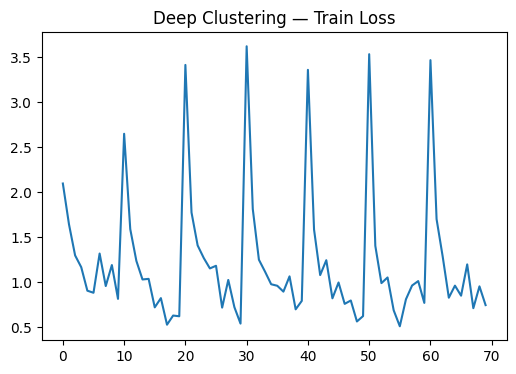

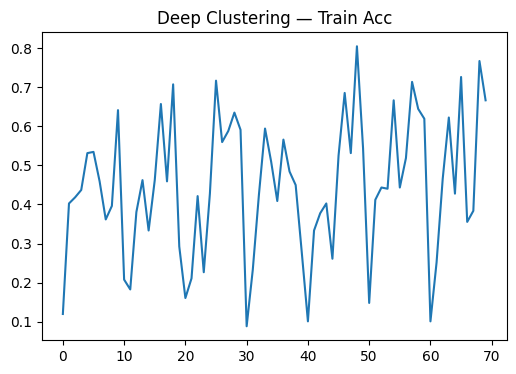

In [9]:

C = PRETEXT_CLUSTERS
dc_model = make_headed_model(base_model, out_dim=C, dropout=0.2)
optimizer_dc = torch.optim.AdamW(dc_model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion_dc = nn.CrossEntropyLoss()

history_dc = {"cycle":[], "train_loss":[], "train_acc":[], "unique_clusters":[]}

for cycle in range(1, DC_CYCLES+1):
    print(f"\n=== Deep Clustering cycle {cycle}/{DC_CYCLES} ===")
    # 1) extract features on train (no aug) with current model weights
    feats = extract_features_from_model(dc_model, train_feat_loader, pca_dim=PCA_DIM, l2_norm=L2_NORMALIZE)
    # 2) k-means
    ok = False
    for attempt in range(5):
        km = KMeans(n_clusters=C, n_init=10, random_state=SEED+cycle+attempt)
        cluster_ids = km.fit_predict(feats)
        uniq = np.unique(cluster_ids)
        if len(uniq) >= max(2, C//2):  # avoid collapse
            ok = True; break
    if not ok:
        print("Warning: k-means collapse, reducing clusters to", len(uniq))
        C = len(uniq)
        dc_model = make_headed_model(base_model, out_dim=C, dropout=0.2)  # reinit head
        optimizer_dc = torch.optim.AdamW(dc_model.parameters(), lr=3e-4, weight_decay=1e-4)
        criterion_dc = nn.CrossEntropyLoss()

    print("Unique clusters:", len(np.unique(cluster_ids)))
    # 3) build pseudo-label dataset with BALANCED sampling across clusters
    counts = np.bincount(cluster_ids, minlength=C)
    weights = 1.0/(counts + 1e-6)

    class PseudoClusterDS(Dataset):
        def __init__(self, base_ds, pseudo_y):
            self.base_ds = base_ds; self.pseudo_y = pseudo_y
        def __len__(self): return len(self.base_ds)
        def __getitem__(self, idx):
            x,_,idc = self.base_ds[idx]
            return x, int(self.pseudo_y[idx]), idc

    pseudo_ds = PseudoClusterDS(train_ds, cluster_ids)
    sample_w = [weights[c] for c in cluster_ids]
    sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
    pseudo_loader = DataLoader(pseudo_ds, batch_size=DC_BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

    # 4) train a few epochs to predict clusters
    for ep in range(1, DC_EPOCHS_PER_CYCLE+1):
        tr_loss, tr_acc = train_epoch(dc_model, pseudo_loader, optimizer_dc, criterion_dc)
        print(f"[cycle {cycle}] ep {ep}/{DC_EPOCHS_PER_CYCLE} | loss={tr_loss:.4f} acc={tr_acc:.4f}")
        history_dc["cycle"].append(cycle); history_dc["train_loss"].append(tr_loss)
        history_dc["train_acc"].append(tr_acc); history_dc["unique_clusters"].append(int(len(np.unique(cluster_ids))))

# Plot pretext trends
plt.figure(figsize=(6,4)); plt.plot(history_dc["train_loss"]); plt.title("Deep Clustering — Train Loss"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(history_dc["train_acc"]);  plt.title("Deep Clustering — Train Acc");  plt.show()


def mixup_data(x, y, alpha=0.4):
    if alpha <= 0: 
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


def train_epoch(model, loader, opt, crit, use_mixup=USE_MIXUP, alpha=MIXUP_ALPHA):
    model.train()
    tot_loss, tot_correct, n = 0.0, 0, 0
    for x,y,_ in loader:
        x,y = x.to(device), y.to(device)
        if use_mixup:
            x, y_a, y_b, lam = mixup_data(x, y, alpha=alpha)
            logits = model(x)
            loss = lam*crit(logits, y_a) + (1-lam)*crit(logits, y_b)
        else:
            logits = model(x)
            loss = crit(logits, y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        opt.step()
        preds = logits.argmax(1)
        tot_loss += loss.item()*x.size(0)
        tot_correct += (preds==y).sum().item()
        n += x.size(0)
    return tot_loss/n, tot_correct/n


@torch.no_grad()
def eval_metrics_tta(model, loader, tta=TTA_K):
    model.eval()
    all_logits, all_y = [], []
    for x,y,_ in loader:
        x = x.to(device)
        logits_sum = 0
        reps = tta if USE_TTA else 1
        for k in range(reps):
            if k==0: x_aug = x
            elif k==1: x_aug = torch.flip(x, dims=[3])
            elif k==2: x_aug = x.transpose(2,3)
            else:      x_aug = torch.flip(x.transpose(2,3), dims=[3])
            logits_sum += model(x_aug)
        logits = (logits_sum / reps).cpu()
        all_logits.append(logits); all_y.append(y)
    logits = torch.cat(all_logits).numpy()
    y = torch.cat(all_y).numpy()
    preds = logits.argmax(1)
    acc = (preds==y).mean()
    return acc, preds, y, logits


## 8) Supervised Binary Fine-Tuning (HPO → Final)


=== HPO: lr=0.0001, wd=1e-05, dropout=0.2 ===
Val F1=0.5234 Acc=0.6029

=== HPO: lr=0.0001, wd=1e-05, dropout=0.4 ===
Val F1=0.4775 Acc=0.5147

=== HPO: lr=0.0001, wd=0.0001, dropout=0.2 ===
Val F1=0.4655 Acc=0.5294

=== HPO: lr=0.0001, wd=0.0001, dropout=0.4 ===
Val F1=0.4213 Acc=0.5147

=== HPO: lr=0.0003, wd=1e-05, dropout=0.2 ===
Val F1=0.6351 Acc=0.6618

=== HPO: lr=0.0003, wd=1e-05, dropout=0.4 ===
Val F1=0.6218 Acc=0.6324

=== HPO: lr=0.0003, wd=0.0001, dropout=0.2 ===
Val F1=0.6124 Acc=0.6471

=== HPO: lr=0.0003, wd=0.0001, dropout=0.4 ===
Val F1=0.5968 Acc=0.6471


,lr,wd,dropout,val_acc,val_f1
0,0.0003,0.00001,0.2,0.661765,0.635101
1,0.0003,0.00001,0.4,0.632353,0.621849
2,0.0003,0.00010,0.2,0.647059,0.612424
3,0.0003,0.00010,0.4,0.647059,0.596752
4,0.0001,0.00001,0.2,0.602941,0.523360
5,0.0001,0.00001,0.4,0.514706,0.477526
6,0.0001,0.00010,0.2,0.529412,0.465541
7,0.0001,0.00010,0.4,0.514706,0.421265


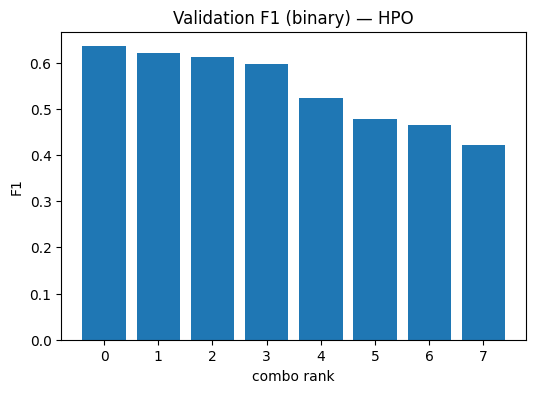

Best HP: {'lr': 0.0003, 'wd': 1e-05, 'dropout': 0.2} Best F1: 0.6351005668865621
[Final] ep 1/15 | loss=0.5687 | val_f1=0.4713 (acc=0.5735)
[Final] ep 2/15 | loss=0.4282 | val_f1=0.6295 (acc=0.6471)
[Final] ep 3/15 | loss=0.3911 | val_f1=0.6128 (acc=0.6618)
[Final] ep 4/15 | loss=0.3810 | val_f1=0.6275 (acc=0.6618)
[Final] ep 5/15 | loss=0.3299 | val_f1=0.6940 (acc=0.7500)
[Final] ep 6/15 | loss=0.2236 | val_f1=0.6543 (acc=0.6912)
[Final] ep 7/15 | loss=0.3142 | val_f1=0.6746 (acc=0.7500)
[Final] ep 8/15 | loss=0.2779 | val_f1=0.6380 (acc=0.7059)
[Final] ep 9/15 | loss=0.2085 | val_f1=0.6675 (acc=0.7353)
[Final] ep 10/15 | loss=0.2607 | val_f1=0.6864 (acc=0.7500)
[Final] ep 11/15 | loss=0.2810 | val_f1=0.6561 (acc=0.7059)
[Final] ep 12/15 | loss=0.2810 | val_f1=0.7200 (acc=0.7353)
[Final] ep 13/15 | loss=0.1796 | val_f1=0.7120 (acc=0.7206)
[Final] ep 14/15 | loss=0.2265 | val_f1=0.7340 (acc=0.7353)
[Final] ep 15/15 | loss=0.2528 | val_f1=0.6627 (acc=0.7206)


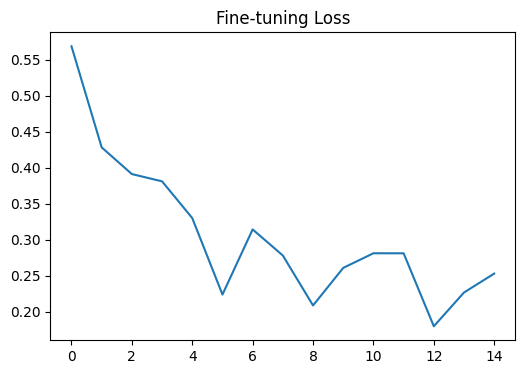

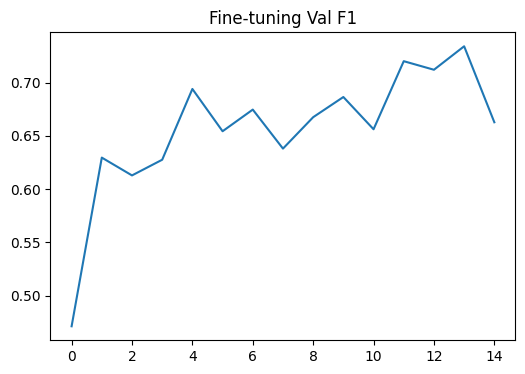

In [10]:

NUM_CLASSES = 5

def make_finetune_model(from_model, num_out, dropout_p):
    # copy weights, replace head
    m = copy.deepcopy(from_model)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(nn.Dropout(p=dropout_p, inplace=True), nn.Linear(in_features, num_out))
    return m.to(device)

# class imbalance weights
counts = train_df["label"].value_counts().sort_index().values
counts = train_df["label"].value_counts().sort_index().values
class_weights = torch.tensor(1.0/(counts + 1e-6), dtype=torch.float32).to(device)
cb_weights = torch.tensor(effective_num_weights_numpy(train_df["label"].values, beta=CB_BETA), dtype=torch.float32).to(device)

# HPO
results = []
best = {"f1": -1, "hp": None, "state": None}
for lr in SWEEP_LR:
    for wd in SWEEP_WD:
        for dp in SWEEP_DROPOUT:
            print(f"\n=== HPO: lr={lr}, wd={wd}, dropout={dp} ===")
            model = make_finetune_model(dc_model, NUM_CLASSES, dropout_p=dp)
            crit = FocalLoss(weight=cb_weights, gamma=FOCAL_GAMMA) if LOSS_NAME=="cb_focal" else nn.CrossEntropyLoss(weight=class_weights)
            opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=SWEEP_EPOCHS)

            # train for SWEEP_EPOCHS
            for ep in range(1, SWEEP_EPOCHS+1):
                loss, acc = train_epoch(model, train_loader, opt, crit)
                sch.step()

            # val
            v_acc, _, v_y, v_logits = eval_metrics(model, val_loader)
            v_pred = v_logits.argmax(1)
            v_f1 = f1_score(v_y, v_pred, average="macro")
            results.append({"lr":lr,"wd":wd,"dropout":dp,"val_acc":v_acc,"val_f1":v_f1})
            print(f"Val F1={v_f1:.4f} Acc={v_acc:.4f}")
            if v_f1 > best["f1"]:
                best["f1"] = v_f1
                best["hp"] = {"lr":lr,"wd":wd,"dropout":dp}
                best["state"] = copy.deepcopy(model.state_dict())

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df)

plt.figure(figsize=(6,4)); plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("Validation F1 (binary) — HPO"); plt.xlabel("combo rank"); plt.ylabel("F1"); plt.show()

print("Best HP:", best["hp"], "Best F1:", best["f1"])

# Final training with best HP
hp = best["hp"]
ft_model = make_finetune_model(dc_model, NUM_CLASSES, dropout_p=hp["dropout"])
crit = FocalLoss(weight=cb_weights, gamma=FOCAL_GAMMA) if LOSS_NAME=="cb_focal" else nn.CrossEntropyLoss(weight=class_weights)
opt = torch.optim.AdamW(ft_model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINAL_EPOCHS)

hist = {"train_loss":[], "val_f1":[]}
best_val_f1, best_state = -1, None

for ep in range(1, FINAL_EPOCHS+1):
    tr_loss, tr_acc = train_epoch(ft_model, train_loader, opt, crit)
    sch.step()
    v_acc, _, v_y, v_logits = eval_metrics(ft_model, val_loader)
    v_pred = v_logits.argmax(1)
    v_f1 = f1_score(v_y, v_pred, average="macro")
    hist["train_loss"].append(tr_loss); hist["val_f1"].append(v_f1)
    print(f"[Final] ep {ep}/{FINAL_EPOCHS} | loss={tr_loss:.4f} | val_f1={v_f1:.4f} (acc={v_acc:.4f})")
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1; best_state = copy.deepcopy(ft_model.state_dict())

ft_model.load_state_dict(best_state)

plt.figure(figsize=(6,4)); plt.plot(hist["train_loss"]); plt.title("Fine-tuning Loss"); plt.show()
plt.figure(figsize=(6,4)); plt.plot(hist["val_f1"]);   plt.title("Fine-tuning Val F1"); plt.show()


## 9) Test Evaluation & Plots

Test Accuracy: 0.6667 | Test F1 (macro): 0.6058

Classification Report (5 classes, Test):
                   precision    recall  f1-score   support

        No DR (0)     0.9444    0.8500    0.8947        20
         Mild (1)     0.4000    0.6667    0.5000         3
     Moderate (2)     0.7391    0.7083    0.7234        24
       Severe (3)     0.3846    0.3846    0.3846        13
Proliferative (4)     0.5000    0.5556    0.5263         9

         accuracy                         0.6667        69
        macro avg     0.5936    0.6330    0.6058        69
     weighted avg     0.6859    0.6667    0.6738        69



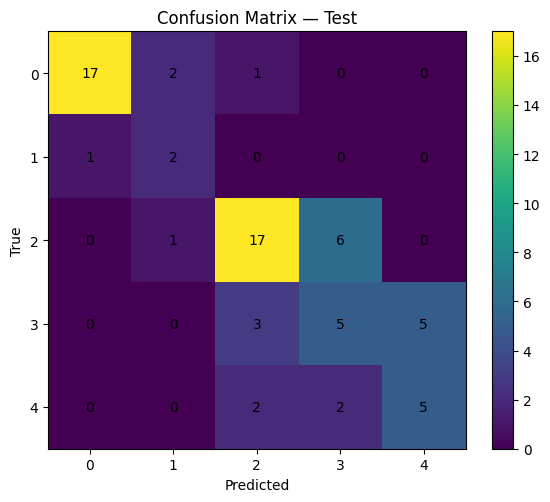

Macro ROC-AUC: 0.9088 | Macro AP: 0.6542


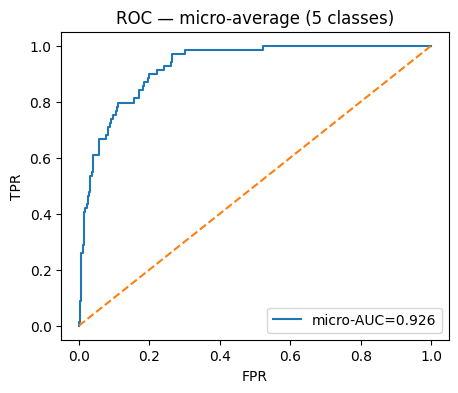

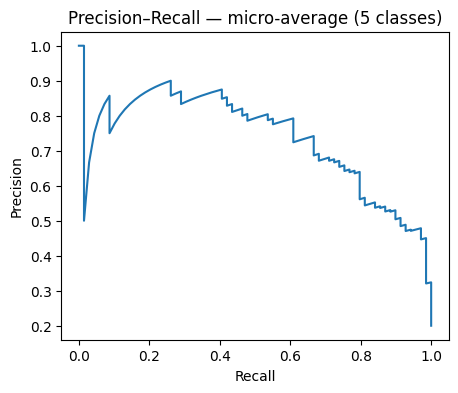

In [13]:

# Test
t_acc, _, t_y, t_logits = eval_metrics_tta(ft_model, test_loader, tta=TTA_K)
t_pred = t_logits.argmax(1)
t_f1 = f1_score(t_y, t_pred, average="macro")
print(f"Test Accuracy: {t_acc:.4f} | Test F1 (macro): {t_f1:.4f}")

# Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report (5 classes, Test):")
print(classification_report(t_y, t_pred, target_names=["No DR (0)","Mild (1)","Moderate (2)","Severe (3)","Proliferative (4)"], digits=4))

cm = confusion_matrix(t_y, t_pred, labels=[0,1,2,3,4])
plt.figure(figsize=(6,5)); plt.imshow(cm, interpolation='nearest'); plt.title("Confusion Matrix — Test")
plt.colorbar(); plt.xticks([0,1,2,3,4], ["0","1","2","3","4"]); plt.yticks([0,1,2,3,4], ["0","1","2","3","4"]);
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,str(cm[i,j]),ha="center",va="center")
plt.tight_layout(); plt.show()

# ROC & PR (multi-class)
probs_full = torch.softmax(torch.tensor(t_logits), dim=1).numpy()
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

Y_bin = label_binarize(t_y, classes=[0,1,2,3,4])

# Macro AUC / AP
auc_macro = roc_auc_score(Y_bin, probs_full, average="macro", multi_class="ovr")
ap_macro  = average_precision_score(Y_bin, probs_full, average="macro")
print(f"Macro ROC-AUC: {auc_macro:.4f} | Macro AP: {ap_macro:.4f}")

# Micro-averaged curves
fpr_micro, tpr_micro, _ = roc_curve(Y_bin.ravel(), probs_full.ravel())
plt.figure(figsize=(5,4)); plt.plot(fpr_micro, tpr_micro, label=f"micro-AUC={roc_auc_score(Y_bin, probs_full, average='micro', multi_class='ovr'):.3f}")
plt.plot([0,1],[0,1],linestyle="--"); plt.title("ROC — micro-average (5 classes)"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.show()

prec_micro, rec_micro, _ = precision_recall_curve(Y_bin.ravel(), probs_full.ravel())
plt.figure(figsize=(5,4)); plt.plot(rec_micro, prec_micro)
plt.title("Precision–Recall — micro-average (5 classes)"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.show()

## 10) Save Artifacts

In [14]:

OUT = Path("./outputs"); OUT.mkdir(parents=True, exist_ok=True)
torch.save(ft_model.state_dict(), OUT/"best_model_multiclass_deepclust.pth")

import json as _json
with open(OUT/"best_ft_hparams.json","w") as f:
    _json.dump(dict(best_hp=best["hp"]), f, indent=2)

# test preds
pd.DataFrame({"id_code": test_df["id_code"].values,
              "true": test_df["label"].values,
              "pred": t_pred}).to_csv(OUT/"test_predictions_multiclass_deepclust.csv", index=False)

print("Saved:", OUT/"best_model_multiclass_deepclust.pth",
      OUT/"best_ft_hparams.json", OUT/"test_predictions_multiclass_deepclust.csv")


Saved: outputs/best_model_multiclass_deepclust.pth outputs/best_ft_hparams.json outputs/test_predictions_multiclass_deepclust.csv
